In [251]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

In [252]:
df=pd.read_csv("Telecom_KPI_30Days_5Sites.csv")
df.drop_duplicates(inplace=True)
df['Timestamp']=pd.to_datetime(df['Timestamp'])
#df.dropna()
df['Timestamp']=df['Timestamp'].fillna(df['Timestamp'].mean())
df['RSRP']=df['RSRP'].fillna(df['RSRP'].mean())
df['SINR']=df['SINR'].fillna(df['SINR'].mean())
df['Throughput']=df['Throughput'].fillna(df['Throughput'].mean())
df['Latency']=df['Latency'].fillna(df['Latency'].mean())
df['Packet_Loss']=df['Packet_Loss'].fillna(df['Packet_Loss'].mean())
df['Connected_Users']=df['Connected_Users'].fillna(df['Connected_Users'].mean())
df.sort_values(by='Timestamp',inplace=True)
df.head()

C:\Users\Soham Sood\AppData\Local\Temp\ipykernel_12996\1962446084.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp']=pd.to_datetime(df['Timestamp'])


,Timestamp,RSRP,SINR,Latency,Throughput,Packet_Loss,Connected_Users,Network_Status,Site_ID,Hour
3867,2026-01-01,-87.90,23.80,33.29,130.62,1.21,39,Healthy,Site_E,0
42021,2026-01-01,-92.73,12.81,43.20,63.93,0.37,176,Degraded,Site_D,0
6099,2026-01-01,-78.59,25.72,46.39,50.21,0.26,252,Degraded,Site_C,0
8456,2026-01-01,-95.36,15.59,28.35,94.19,0.56,178,Degraded,Site_B,0
28887,2026-01-01,-84.74,17.67,40.49,60.82,0.80,217,Healthy,Site_A,0


In [253]:
def daily_plot(kpi):
    df['date']=df['Timestamp'].dt.date
    rsrp_daily=df.groupby(['date','Site_ID'])[kpi].mean().reset_index()
    for site in rsrp_daily['Site_ID'].unique():
        site_data=rsrp_daily[rsrp_daily['Site_ID']==site]
        plt.plot(site_data['date'],site_data[kpi],label=site)
    plt.title(f"Daily {kpi} for every site")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

def weekly_plot(kpi):
    df['date']=df['Timestamp'].dt.isocalendar().week
    rsrp_daily=df.groupby(['date','Site_ID'])[kpi].mean().reset_index()
    for site in rsrp_daily['Site_ID'].unique():
        site_data=rsrp_daily[rsrp_daily['Site_ID']==site]
        plt.plot(site_data['date'],site_data[kpi],label=site)
    plt.title(f"Weekly {kpi} for every site")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

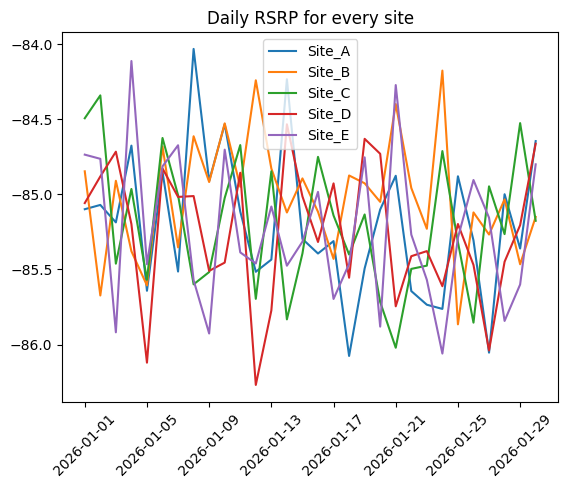

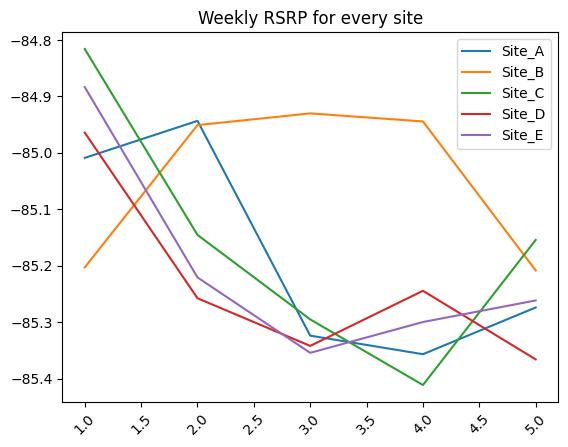

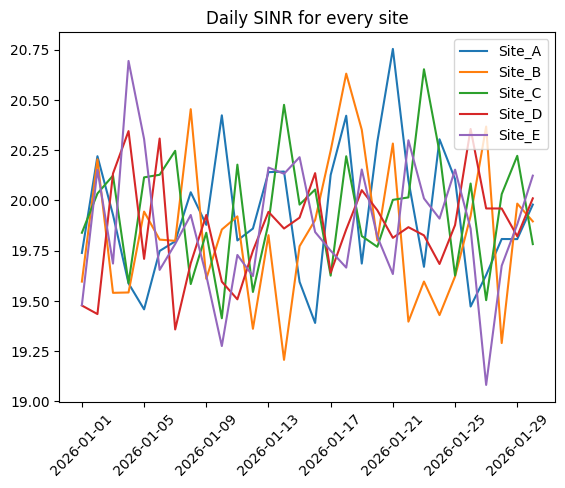

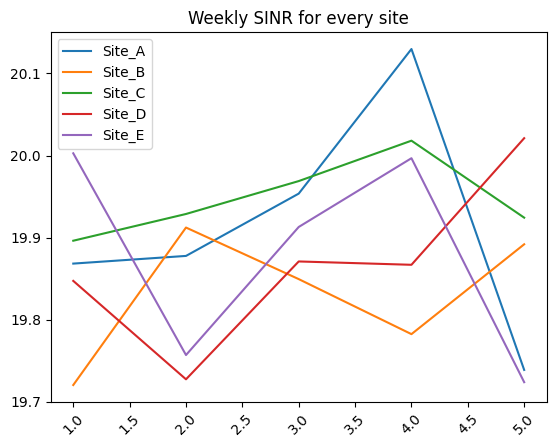

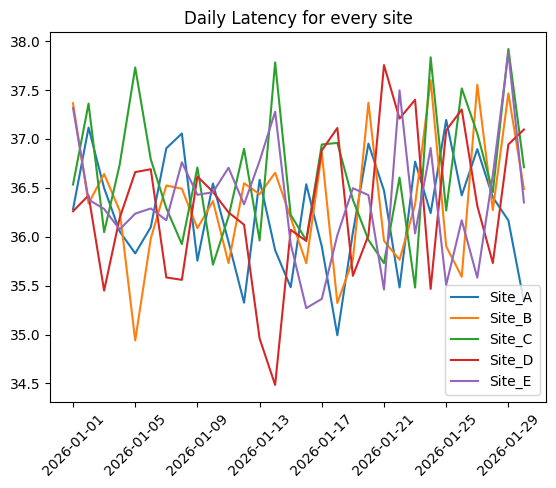

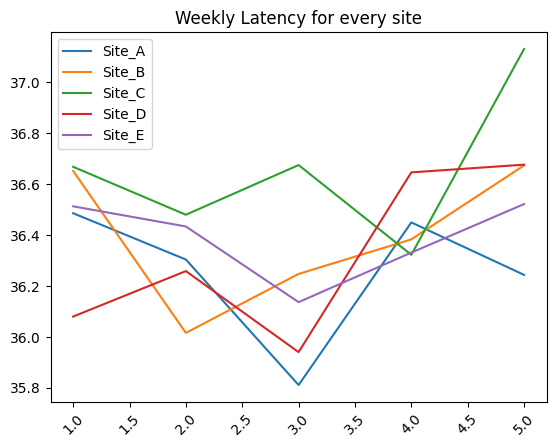

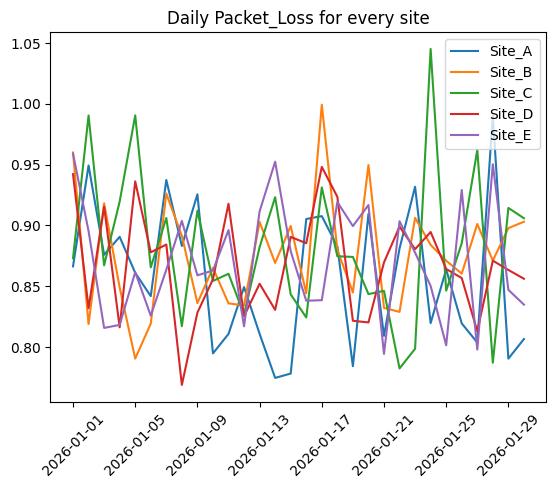

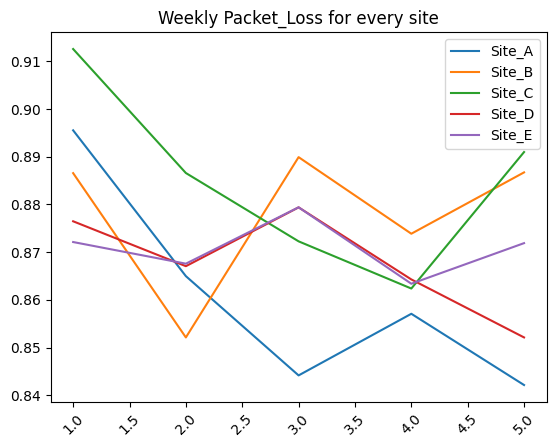

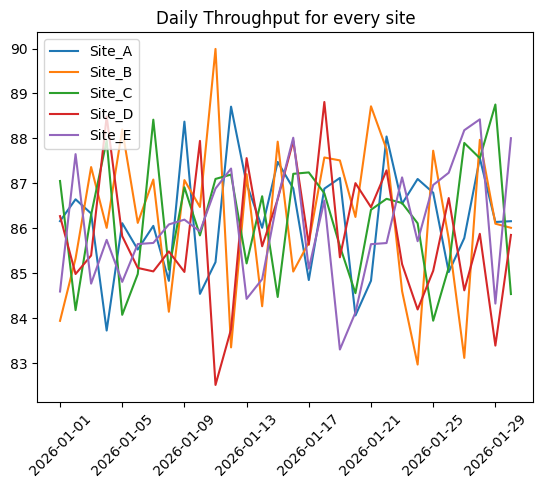

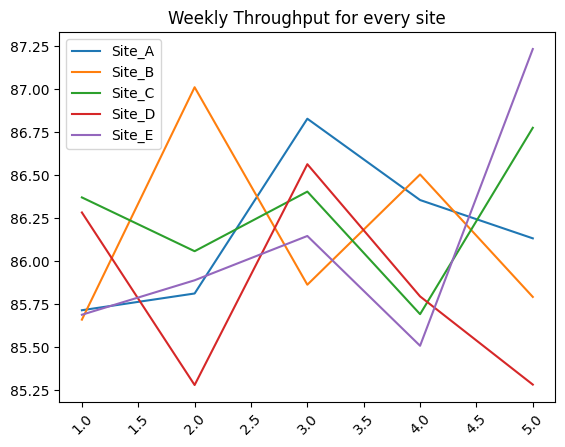

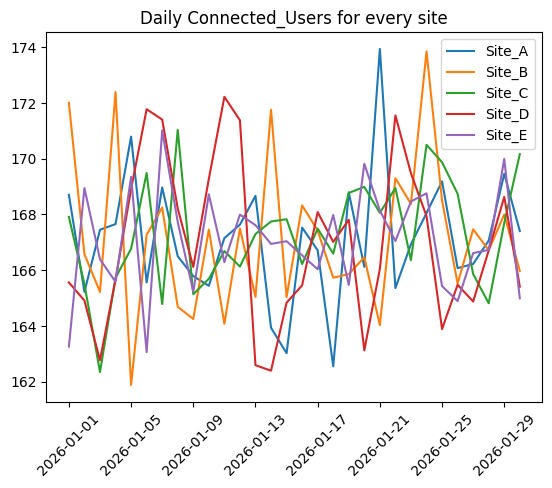

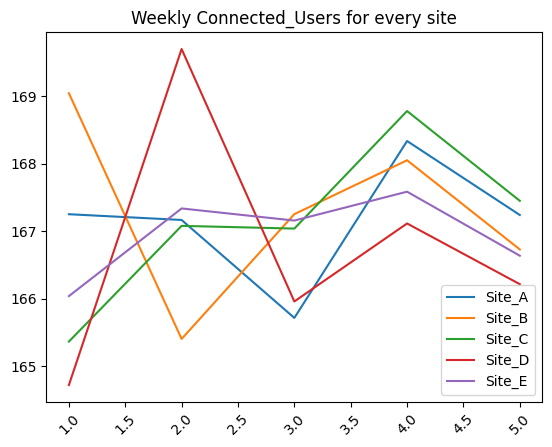

In [254]:
daily_plot("RSRP")
weekly_plot("RSRP")
daily_plot("SINR")
weekly_plot("SINR")
daily_plot("Latency")
weekly_plot("Latency")
daily_plot("Packet_Loss")
weekly_plot("Packet_Loss")
daily_plot("Throughput")
weekly_plot("Throughput")
daily_plot("Connected_Users")
weekly_plot("Connected_Users")

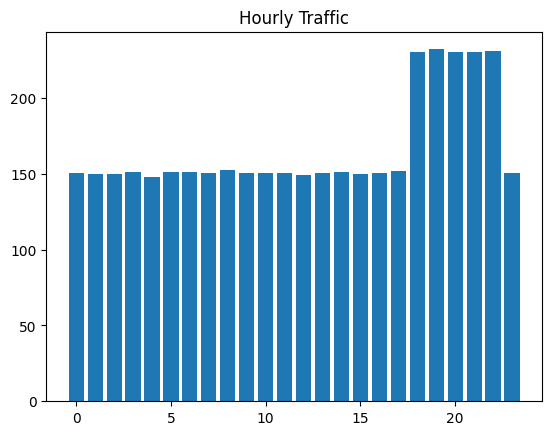

In [255]:
hourly=df.groupby('Hour')['Connected_Users'].mean()
plt.bar(hourly.index,hourly.values)
plt.title("Hourly Traffic")
plt.show()

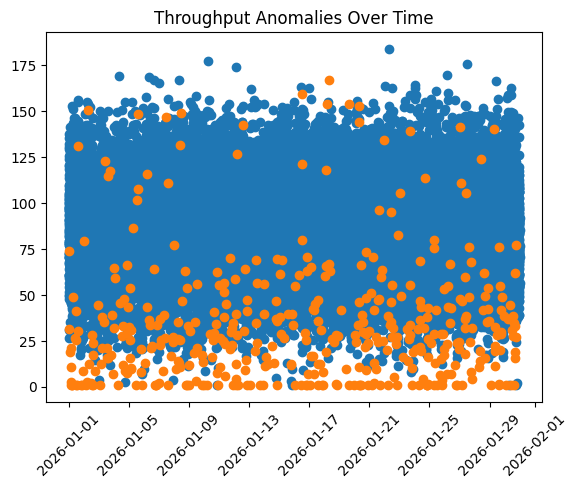

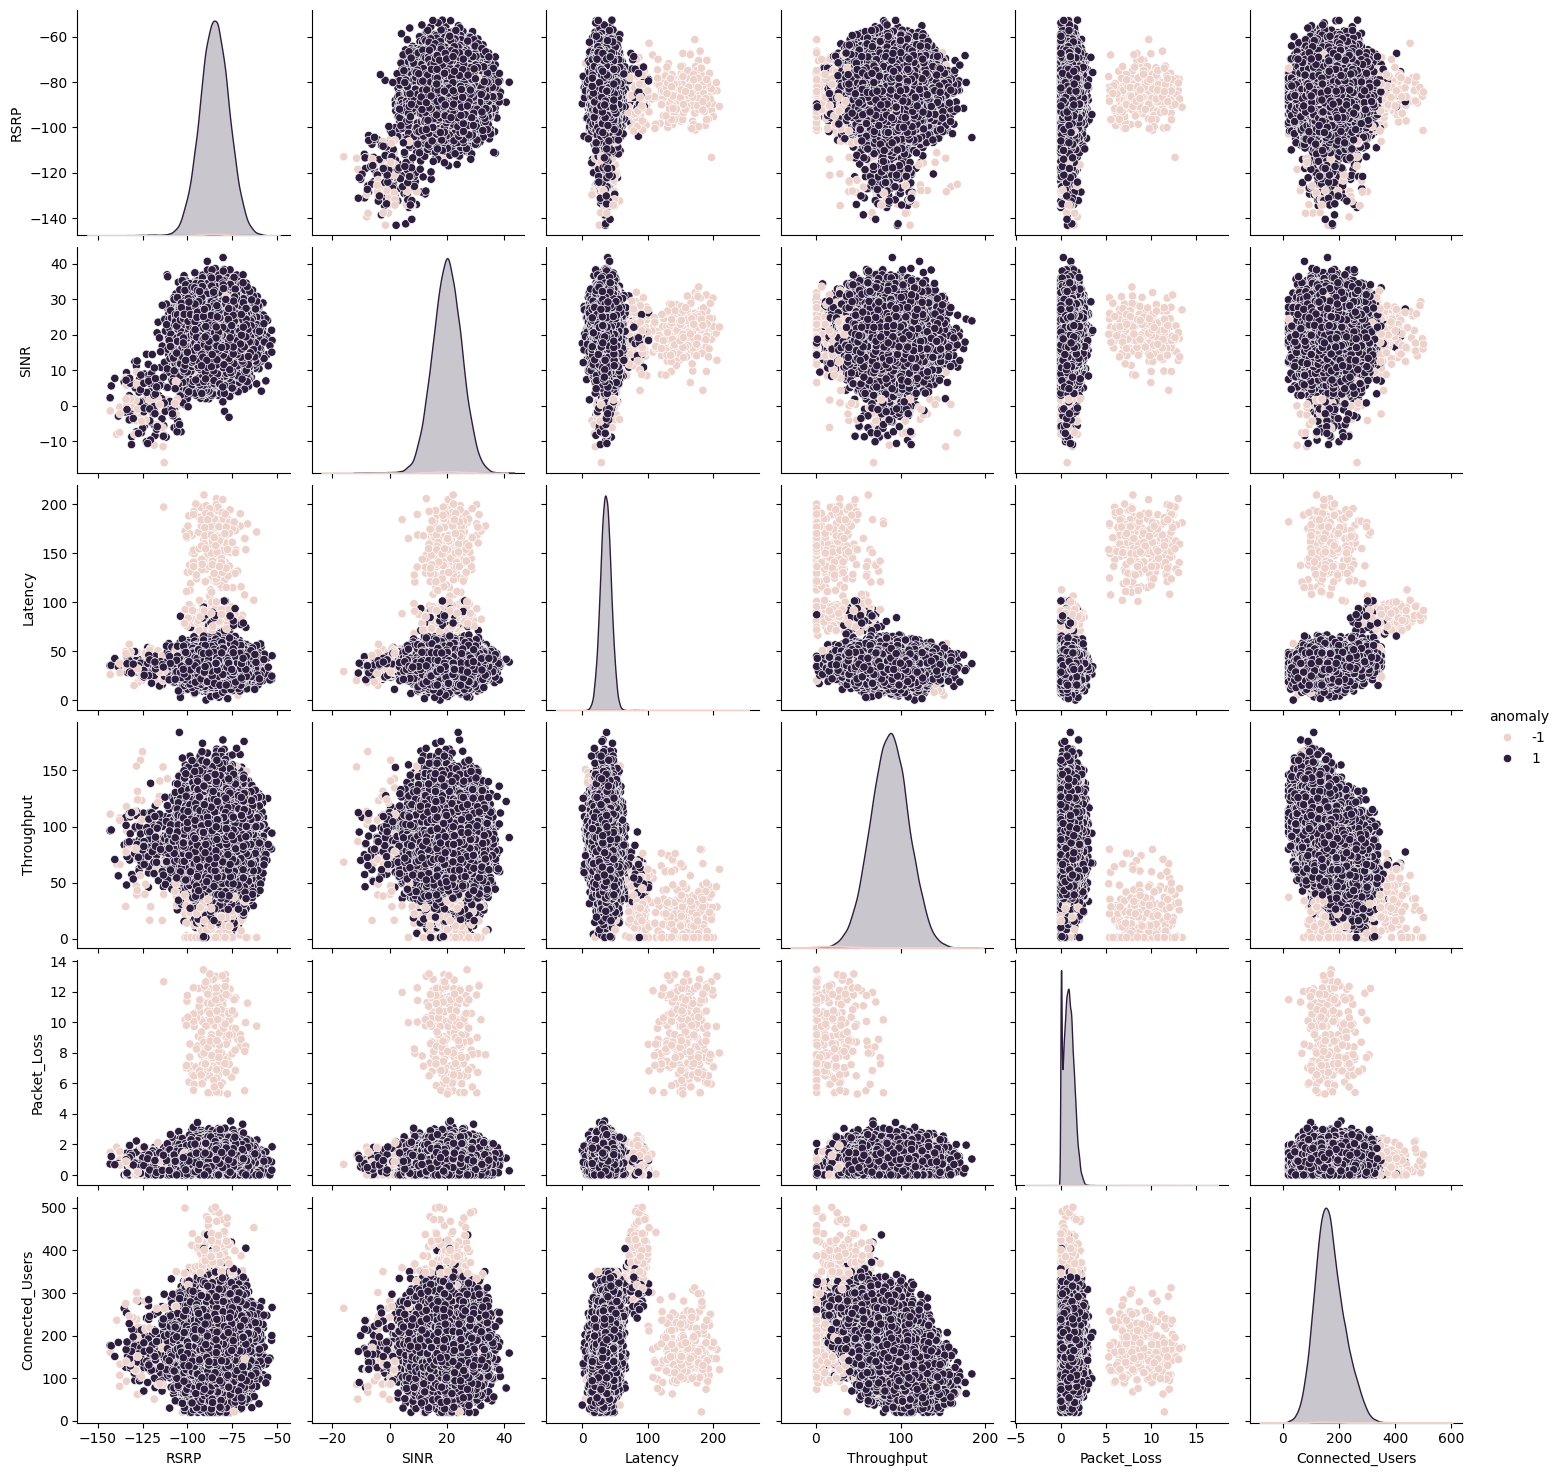

In [256]:
anomaly_inputs=df.drop(columns=['Timestamp','Network_Status','Site_ID','Hour','date'])
pipe=Pipeline([('scale',StandardScaler()),('model',IsolationForest(contamination=0.01,random_state=42))])
pipe.fit(anomaly_inputs)
df['anomaly_score']=pipe.decision_function(anomaly_inputs)
df['anomaly']=pipe.predict(anomaly_inputs)
df['anomaly'].value_counts()
anomalies=df[df['anomaly']==-1]
normal=df[df['anomaly']==1]
plt.scatter(normal['Timestamp'],normal['Throughput'])
plt.scatter(anomalies['Timestamp'],anomalies['Throughput'])
plt.title('Throughput Anomalies Over Time')
plt.xticks(rotation=45)
plt.show()
sns.pairplot(df,vars=anomaly_inputs,hue='anomaly')

In [277]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader,TensorDataset
df.sort_values(['Site_ID','Timestamp'],inplace=True)
scaler= StandardScaler()
window=24
sequences=[]
for site in df['Site_ID'].unique():
    site_data=df[df['Site_ID']==site]
    site_data=site_data.drop(columns=['Timestamp','Site_ID','Network_Status','anomaly_score','anomaly','Hour','date'])
    site_data=scaler.fit_transform(site_data)
    for i in range(len(site_data)-window+1):
        sequences.append(site_data[i:i+window])
X_train,X_test=train_test_split(sequences,test_size=0.2,random_state=42)
X_train=torch.tensor(X_train,dtype=torch.float32)
training_dataset=TensorDataset(X_train)
train_loader=DataLoader(training_dataset,batch_size=64)
X_test=torch.tensor(X_test,dtype=torch.float32)
testing_dataset=TensorDataset(X_test)
test_loader=DataLoader(testing_dataset,batch_size=64)

In [278]:
class LSTMAutoEncoder(nn.Module):
    def __init__(self):
        super(LSTMAutoEncoder,self).__init__()
        self.lstm1=nn.LSTM(6,64,batch_first=True)
        self.drop1=nn.Dropout(0.2)
        self.lstm2=nn.LSTM(64,32,batch_first=True)
        self.lstm3=nn.LSTM(32,64,batch_first=True)
        self.drop2=nn.Dropout(0.2)
        self.output=nn.Linear(64,6)
    def forward(self,x):
        out,_=self.lstm1(x)
        out=self.drop1(out)
        out,(hidden,cell)=self.lstm2(out)
        encoded=hidden[-1]
        decoded=encoded.unsqueeze(1).repeat(1,x.size(1),1)
        decoded,_=self.lstm3(decoded)
        decoded=self.drop2(decoded)
        out=self.output(decoded)
        return out



In [289]:
model=LSTMAutoEncoder()
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

test_loss_list=[]
train_loss_list=[]
error_list=[]

for epoch in range(50):
    epoch_loss=0
    model.train()
    for batch in train_loader:
        x=batch[0]
        output=model(x)
        loss=criterion(output,x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss+=loss.item()
    epoch_loss/=len(train_loader)
    if (epoch + 1) % 10 == 0:
        print(f'Training:- Epoch {epoch+1}, Loss: {epoch_loss:.4f}')
    train_loss_list.append(epoch_loss)
    val_loss=0
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            x=batch[0]
            output=model(x)
            loss=criterion(output,x)
            val_loss+=loss.item()
        val_loss/=len(test_loader)
        if (epoch + 1) % 10 == 0:
            print(f'Testing:- Epoch {epoch+1}, Loss: {val_loss:.4f}')
        test_loss_list.append(val_loss)

model.eval()
with torch.no_grad():
    for batch in test_loader:
        x=batch[0]
        output=model(x)
        error = torch.mean((x - output) ** 2,dim=(1, 2))
        error_list.extend(error.numpy())


Training:- Epoch 10, Loss: 0.7471
Testing:- Epoch 10, Loss: 0.7660
Training:- Epoch 20, Loss: 0.7035
Testing:- Epoch 20, Loss: 0.6840
Training:- Epoch 30, Loss: 0.6835
Testing:- Epoch 30, Loss: 0.7135
Training:- Epoch 40, Loss: 0.6542
Testing:- Epoch 40, Loss: 0.6286
Training:- Epoch 50, Loss: 0.6433
Testing:- Epoch 50, Loss: 0.6137


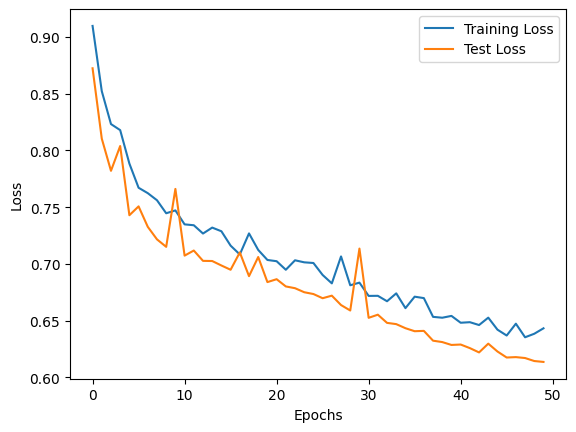

In [290]:
plt.plot(train_loss_list,label='Training Loss')
plt.plot(test_loss_list,label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [294]:
threshold_values={90,95,99}
threshold_results=[]
for percentile in threshold_values:
    threshold = np.percentile(error_list,percentile)
    anomalies = error_list > threshold
    detected_anomalies = np.sum(anomalies)
    threshold_results.append([percentile,threshold,detected_anomalies])
threshold_df=pd.DataFrame(threshold_results,columns=["Threshold","Threshold Value","No of Anomalies detected"])
threshold_df

,Threshold,Threshold Value,No of Anomalies detected
0,90,0.728458,862
1,99,1.143655,87
2,95,0.786331,431


In [302]:
throughput_series=df.groupby('Timestamp')['Throughput'].mean()
throughput_series.sort_index(inplace=True)
train=throughput_series[:-288]
test=throughput_series[-288:]

In [296]:
!pip install statsmodels

     ---------------------------------------- 9.6/9.6 MB 9.3 MB/s eta 0:00:00
     -------------------------------------- 233.3/233.3 kB 2.4 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [306]:
from statsmodels.tsa.arima.model import ARIMA
arima=ARIMA(train,order=(10,0,5))
arima_model=arima.fit()
forecast_24=arima_model.forecast(steps=288)

c:\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 5min will be used.
  self._init_dates(dates, freq)
c:\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


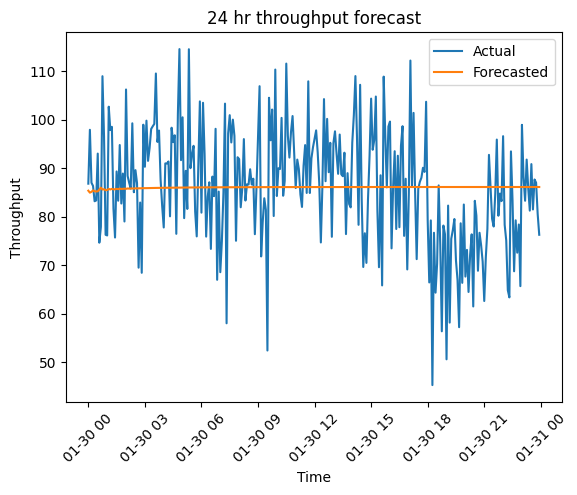

In [307]:
plt.plot(test,label='Actual')
plt.plot(forecast_24,label='Forecasted')
plt.title("24 hr throughput forecast")
plt.xlabel("Time")
plt.ylabel("Throughput")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [321]:
def root_cause_analysis(row):
    if row['RSRP'] < -110:
        return "Poor Radio Coverage"
    elif row['SINR'] < 5:
        return "High Interference"
    elif row['Latency'] > 100:
        return "Network Congestion"
    elif row['Packet_Loss'] > 5:
        return "Backhaul Issues"
    elif row['Throughput'] < 20:
        return "Low Throughput"
    elif row['Connected_Users'] > 350:
        return "High Traffic Load"
    else:
        return "Unknown Network Degradation"

def root_cause_solution(row):
    if row['RSRP'] < -110:
        return "Optimize Antenna Tilt"
    elif row['SINR'] < 5:
        return "Review Neighbouring Cell Config"
    elif row['Latency'] > 100:
        return "Check UPF Utilization"
    elif row['Packet_Loss'] > 5:
        return "Inspect Transport Network"
    elif row['Throughput'] < 20:
        return "Enable Load balancing"
    elif row['Connected_Users'] > 350:
        return "High Traffic Load"
    else:
        return "Solution Unknown"
    
df['Root_Cause']='Nil'
df['Solution']='Nil'
for index,row in df.iterrows():
    if row['anomaly']==-1:
        df.loc[index,'Root_Cause']=root_cause_analysis(row)
        df.loc[index,'Solution']=root_cause_solution(row)
df[df['anomaly']==-1]

,Timestamp,RSRP,SINR,Latency,Throughput,Packet_Loss,Connected_Users,Network_Status,Site_ID,Hour,date,anomaly_score,anomaly,Root_Cause,Solution
7881,2026-01-01 04:50:00,-92.08,23.94,155.90,1.00,10.14,156,Congested,Site_A,4,1,-0.095302,-1,Network Congestion,Check UPF Utilization
23201,2026-01-01 14:15:00,-86.38,20.68,79.15,30.16,0.21,322,Congested,Site_A,14,1,-0.006847,-1,Unknown Network Degradation,Solution Unknown
9499,2026-01-02 12:35:00,-97.31,22.05,150.19,1.00,7.05,130,Congested,Site_A,12,1,-0.087507,-1,Network Congestion,Check UPF Utilization
18165,2026-01-02 13:10:00,-83.85,12.79,205.74,28.23,13.01,167,Congested,Site_A,13,1,-0.088533,-1,Network Congestion,Check UPF Utilization
26675,2026-01-02 14:10:00,-88.80,27.20,85.78,24.08,1.36,370,Congested,Site_A,14,1,-0.061930,-1,High Traffic Load,High Traffic Load
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10666,2026-01-29 09:05:00,-86.78,22.90,150.26,11.25,8.99,227,Congested,Site_E,9,5,-0.093942,-1,Network Congestion,Check UPF Utilization
1059,2026-01-29 15:20:00,-82.11,24.29,136.55,1.38,8.50,212,Congested,Site_E,15,5,-0.094339,-1,Network Congestion,Check UPF Utilization
87,2026-01-29 18:45:00,-90.08,19.92,84.42,28.64,0.16,375,Congested,Site_E,18,5,-0.030334,-1,High Traffic Load,High Traffic Load
41247,2026-01-30 12:55:00,-92.80,12.50,85.13,27.58,1.91,348,Congested,Site_E,12,5,-0.052708,-1,Unknown Network Degradation,Solution Unknown


In [326]:
from sklearn.neighbors import KNeighborsClassifier
def qos_label(row):
    if (row['RSRP']>-90 and row['SINR']>20 and row['Latency']<50 and row['Packet_Loss']<1 and row['Throughput']>80):
        return 'Good'
    elif (row['RSRP']>-110 and row['SINR']>10 and row['Latency']<100 and row['Packet_Loss']<5):
        return 'Fair'
    else:
        return 'Poor'
df['Network_Quality']=df.apply(qos_label,axis=1)
X=df[['RSRP','SINR','Latency','Throughput','Packet_Loss','Connected_Users']]
y=df['Network_Quality']
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)
pipe = Pipeline([('scale',StandardScaler()),
                 ('model',KNeighborsClassifier())
                ])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

In [328]:
df.to_csv("final_kpi_dataset.csv",index=False)
forecast_24.to_csv("forecast.csv")